In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/processed/bank_reviews_sentiment.csv")

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score
0,best app for financial sector,5,2026-05-14,CBE,Google Play,positive,0.999166
1,it's a good application,5,2026-05-13,CBE,Google Play,positive,0.999866
2,thank you cbe,5,2026-05-13,CBE,Google Play,positive,0.999756
3,is good,5,2026-05-13,CBE,Google Play,positive,0.999839
4,wow,5,2026-05-13,CBE,Google Play,positive,0.999592


In [4]:
df["sentiment_label"].value_counts()

sentiment_label
positive    892
negative    576
neutral      10
Name: count, dtype: int64

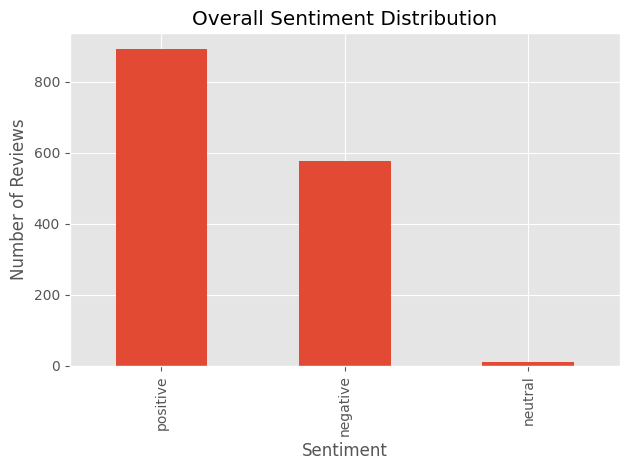

In [5]:
df["sentiment_label"].value_counts().plot(
    kind="bar"
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.savefig("../reports/overall_sentiment_distribution.png")

plt.show()

In [6]:
bank_sentiment = pd.crosstab(
    df["bank"],
    df["sentiment_label"]
)

bank_sentiment

sentiment_label,negative,neutral,positive
bank,,,
BOA,235,3,260
CBE,159,6,316
Dashen,182,1,316


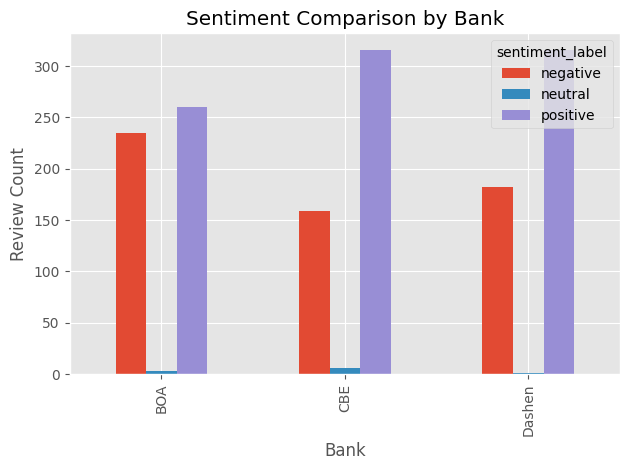

In [7]:
bank_sentiment.plot(kind="bar")

plt.title("Sentiment Comparison by Bank")
plt.xlabel("Bank")
plt.ylabel("Review Count")

plt.tight_layout()

plt.savefig("../reports/sentiment_comparison_by_bank.png")

plt.show()

In [8]:
average_rating = df.groupby("bank")["rating"].mean()

average_rating

bank
BOA       3.556225
CBE       4.087318
Dashen    3.901804
Name: rating, dtype: float64

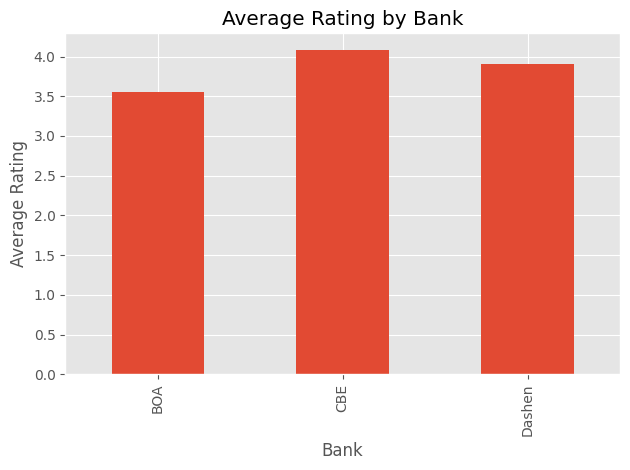

In [9]:
average_rating.plot(kind="bar")

plt.title("Average Rating by Bank")
plt.xlabel("Bank")
plt.ylabel("Average Rating")

plt.tight_layout()

plt.savefig("../reports/average_rating_by_bank.png")

plt.show()

In [10]:
df["sentiment_label"].unique()

<StringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str

In [11]:
negative_reviews = df[
    df["sentiment_label"] == "negative"
]

negative_reviews[[
    "bank",
    "review"
]].head(10)

,bank,review
6,CBE,"Nice, but I can't get some recently transactio..."
7,CBE,Very Secure but very poor interface and limite...
17,CBE,why is my transaction fee hidden? Why doesn't ...
18,CBE,Gal✅😶‍🌫️
20,CBE,እ. በ. ጥ. ነው
23,CBE,this app is so functional for airtime for wall...
26,CBE,There is a a problem when updating the app
30,CBE,Internet Based mobile app for CBEBirr A Intern...
38,CBE,The app is getting worse and worse after every...
40,CBE,is not work properly !!


## Key Insights

1. Negative reviews are primarily associated with login issues, transaction failures, and application crashes.

2. Positive reviews frequently mention convenience, speed, and accessibility.

3. Some banks demonstrate stronger customer satisfaction based on both ratings and sentiment analysis.

4. Authentication and OTP-related problems appear repeatedly across multiple applications.

5. User experience and performance optimization are critical areas for improvement.

## Recommendations

- Improve application stability and crash handling
- Optimize login and OTP verification systems
- Enhance transaction reliability
- Improve user interface responsiveness
- Introduce better customer support integration
- Monitor customer feedback continuously using automated NLP pipelines